# 03 — Stress Testing and VaR Backtesting

**Multi-Asset Portfolio Risk and Stress-Testing Framework**

VaR describes a normal-ish day. This notebook does the other two jobs: asking what happens
on an abnormal one, and then checking whether the VaR models were telling the truth in the
first place.

A VaR model is a falsifiable forecast. At 99% confidence, losses should exceed the one-day
VaR on about 1% of days. That is testable, and most of this notebook is the test.

> **Disclaimer.** Every portfolio in this notebook is a *hypothetical research construct*
> built from publicly available price data. Nothing here represents a real client account,
> real assets under management, investment advice, or a forecast. Stress scenarios are
> analytical assumptions chosen to probe the portfolio, not predictions about markets.


## Setup

In [1]:
import sys, warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from IPython.display import display

from prisk.config import load_config
from prisk import data as dataio, portfolios as pf, metrics as mx
from prisk import risk as rk, stress as stx, backtest as bt, plots

plots.use_style()
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
pd.set_option("display.max_columns", 40)

cfg = load_config()
prices = dataio.load_panel(cfg)
returns = dataio.compute_returns(prices)
holdings = [t for t in cfg.holdings if t in returns.columns]
print(f"{len(prices):,} trading days | {prices.index[0].date()} to {prices.index[-1].date()} | {len(cfg.tickers)} instruments")

results = pf.build_all_portfolios(returns, cfg)
order = ["equal_weight", "minimum_variance", "volatility_target", "benchmark"]
labels = {n: results[n].label for n in order}
weights_map = {n: results[n].latest_weights() for n in order}

window = int(cfg.portfolios["estimation_window"])
cov_recent = pf.estimate_covariance(returns[holdings].iloc[-window:], method="ledoit_wolf")
PORTFOLIO_VALUE = float(cfg.risk["portfolio_value"])

4,855 trading days | 2007-06-01 to 2026-09-17 | 15 instruments


## 1. Historical episode replay

The first family of stress test takes the portfolio's **current** weights and runs them
through the actual returns of a named crisis. The question is not "what did this strategy
earn in 2008" — notebook 01 answered that. It is: *if the Global Financial Crisis happened
again, to the book I hold today, what would it cost me?*

The strength of this approach is internal consistency. The cross-asset correlations, the
volatility path and the sequencing of moves are all real. Nothing is assumed.

The limitation is equally clear: it can only replay crises that have already happened.

Weights are allowed to **drift** during each episode rather than being rebalanced daily.
That is deliberate — daily rebalancing through a crash mechanically buys the fallers and
flatters the result, and it is not what happens to a portfolio nobody trades.

In [2]:
historical = stx.historical_stress_table(returns[holdings], weights_map, cfg)
historical["loss_usd"] = historical["total_return"] * PORTFOLIO_VALUE
pivot = historical.pivot(index="scenario", columns="portfolio", values="total_return")
pivot = pivot[[n for n in order]]
pivot.columns = [labels[n] for n in order]
display(pivot.style.format("{:.2%}").background_gradient(cmap="Reds_r", axis=None))

,Equal Weight,Minimum Variance,Volatility Target 8%,60/40 Benchmark
scenario,,,,
2018 Volatility Spike,-10.79%,-4.54%,-8.54%,-10.72%
2022 Inflation and Rate Shock,-10.07%,-6.97%,-9.94%,-20.51%
COVID-19 Crash,-23.85%,-10.91%,-20.07%,-20.92%
China Devaluation / Oil Collapse,-2.54%,-2.08%,-1.40%,-5.92%
Euro Crisis / U.S. Downgrade,-6.46%,-1.29%,-3.77%,-9.15%
Global Financial Crisis,-29.47%,-11.20%,-22.53%,-30.64%


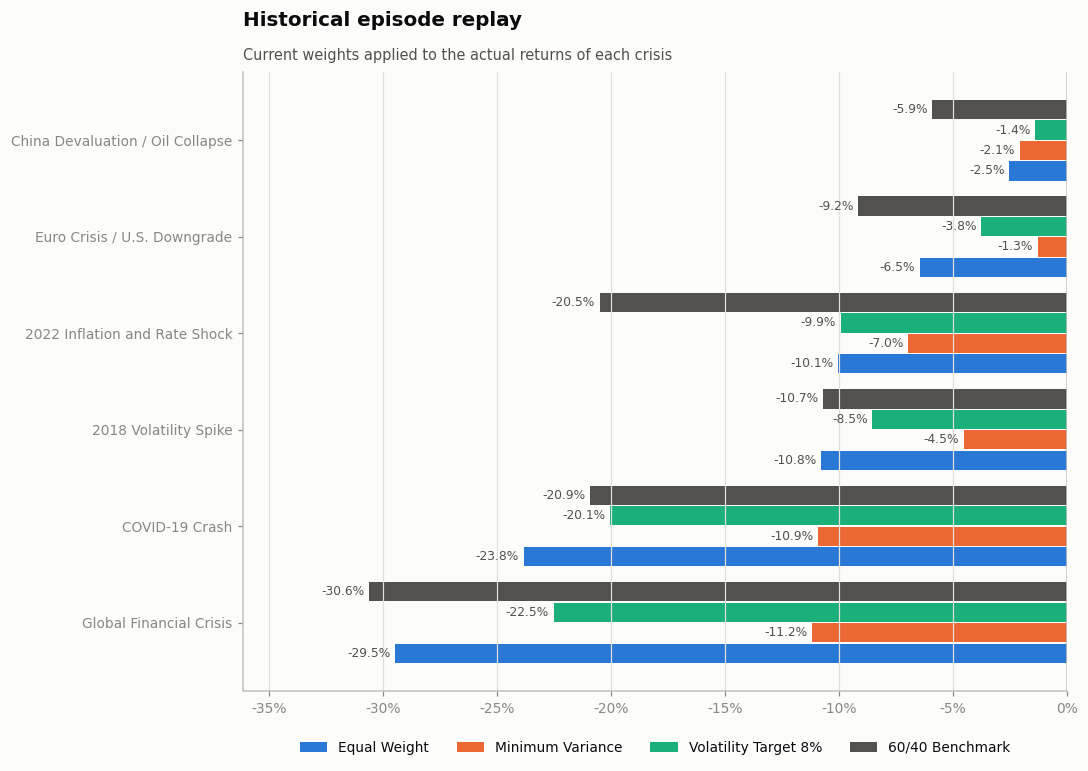

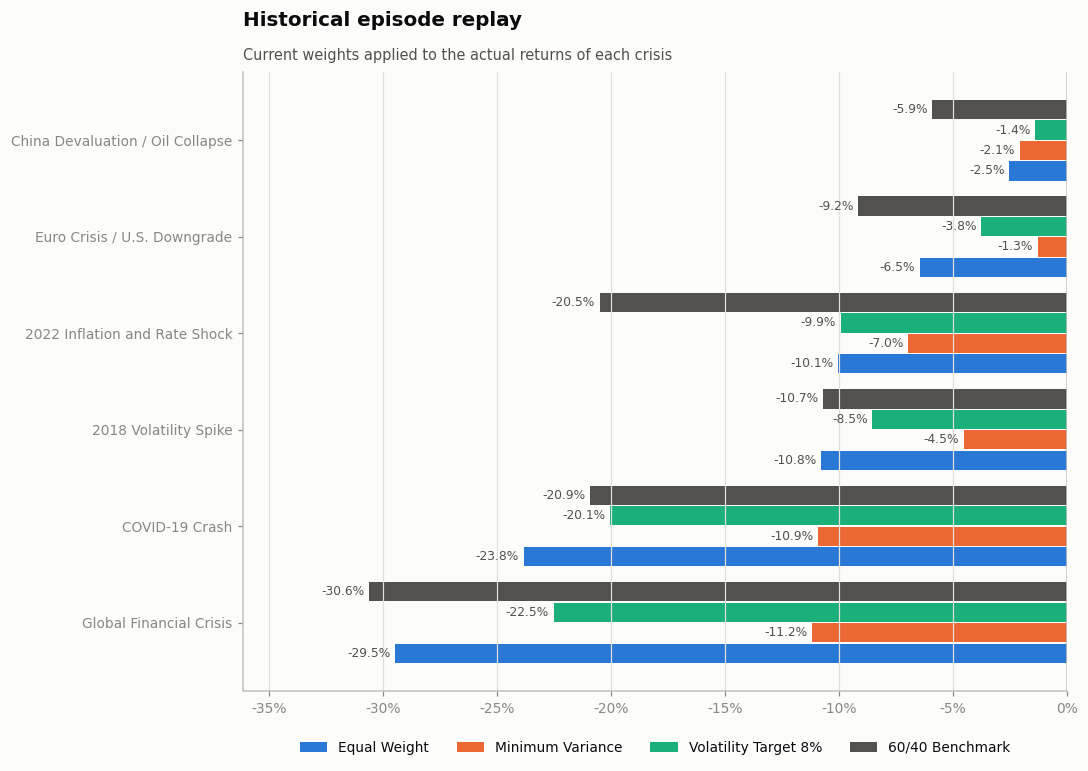

In [3]:
display(plots.plot_episode_comparison(historical, labels))

In [4]:
detail = historical[historical["portfolio"] == "equal_weight"][
    ["scenario", "start", "end", "trading_days", "total_return", "max_drawdown",
     "worst_day", "annualised_volatility", "loss_usd"]]
display(detail.style.format({
    "total_return": "{:.2%}", "max_drawdown": "{:.2%}", "worst_day": "{:.2%}",
    "annualised_volatility": "{:.1%}", "loss_usd": "${:,.0f}"}).hide(axis="index"))

scenario,start,end,trading_days,total_return,max_drawdown,worst_day,annualised_volatility,loss_usd
Global Financial Crisis,2007-10-09,2009-03-09,356,-29.47%,-34.31%,-5.45%,22.6%,"$-294,747"
Euro Crisis / U.S. Downgrade,2011-07-07,2011-10-03,62,-6.46%,-9.24%,-3.57%,18.3%,"$-64,597"
China Devaluation / Oil Collapse,2015-08-10,2016-02-11,129,-2.54%,-8.20%,-2.72%,13.9%,"$-25,408"
COVID-19 Crash,2020-02-19,2020-03-23,24,-23.85%,-24.02%,-6.75%,50.1%,"$-238,496"
2022 Inflation and Rate Shock,2022-01-03,2022-10-12,196,-10.07%,-13.93%,-2.93%,14.8%,"$-100,651"
2018 Volatility Spike,2018-09-20,2018-12-24,66,-10.79%,-11.77%,-2.13%,12.8%,"$-107,909"


### Reading the replay

The **Global Financial Crisis** is the worst episode for three of the four portfolios, and
the 60/40 benchmark is the worst affected of all — a reminder that 40% in bonds is not 40%
of protection when the equity sleeve falls by half.

The **2022 inflation and rate shock** is the row that earns its place. It is the only
episode where the benchmark's losses are not rescued by its bond sleeve, because bonds and
equities fell together. The minimum-variance portfolio, which is structurally long
duration, suffers here relative to how it handled every equity-driven episode.

Note also the volatility-targeted portfolio's GFC number. Its *current* weights carry a
large growth sleeve, because today's forecast volatility is low. Replaying a crisis with
calm-regime positioning shows the mechanism's weakness honestly: the portfolio de-risks
*after* volatility rises, so it enters a fast crash fully exposed.

## 2. Factor sensitivities

The second family of stress test specifies a move in a small set of risk factors and
propagates it through each asset's estimated sensitivity. That lets us express a scenario
with no historical precedent.

Betas come from a **multivariate** OLS regression of each asset on all four factor proxies
jointly. Multivariate matters: SPY and VNQ are highly correlated, so univariate betas would
double-count the equity shock.

By construction each factor proxy loads 1.0 on its own factor and 0.0 on the others, which
is what makes "a -20% equity shock" mean exactly what it says.

In [5]:
betas = stx.estimate_factor_betas(returns[holdings], cfg)
display(betas.style.format("{:.3f}").background_gradient(cmap="RdBu_r", vmin=-1, vmax=1))

,equity,duration,commodity,real_estate
ticker,,,,
AAPL,1.208,0.040,-0.040,-0.113
MSFT,1.242,0.055,-0.080,-0.137
JNJ,0.485,-0.045,-0.067,0.031
JPM,0.755,-0.404,-0.092,0.476
XOM,0.645,-0.139,0.487,0.001
PG,0.466,0.016,-0.085,0.086
CAT,1.000,-0.139,0.234,0.035
NEE,0.569,0.204,-0.015,0.147
SPY,1.000,0.000,-0.000,-0.000


**Sign convention — the thing most likely to be misread.** Every shock is a
*total return on the factor proxy*, not a move in a yield. The `duration` factor is the
return on 20y+ Treasuries, so **a rise in interest rates is a negative duration shock**.

The regression validates the framing rather than assuming it: AGG's duration beta of
roughly 0.35 against TLT is consistent with their relative effective durations (about 6
years versus 17). A +200bp parallel shift implies roughly -30% on TLT, and the beta then
delivers about -11% on AGG without anyone having to assert it.

## 3. Hypothetical scenarios

In [6]:
hypothetical = stx.hypothetical_stress_table(
    returns[holdings], weights_map, cfg, cov=cov_recent, portfolio_value=PORTFOLIO_VALUE)
grid = hypothetical.pivot(index="scenario", columns="portfolio", values="portfolio_impact")
grid = grid[[n for n in order]]
grid.columns = [labels[n] for n in order]
display(grid.style.format("{:.2%}").background_gradient(cmap="Reds_r", axis=None))

,Equal Weight,Minimum Variance,Volatility Target 8%,60/40 Benchmark
scenario,,,,
Commodity Collapse,-9.23%,-6.59%,-8.55%,-5.88%
Equity Bear Market,-12.07%,-4.50%,-9.57%,-12.19%
Rate Shock (+200bp),-7.28%,-5.72%,-8.05%,-8.39%
Severe Combined Stress,-22.75%,-13.32%,-21.10%,-21.92%
Stagflation: Equity + Rate Shock,-14.19%,-5.34%,-12.08%,-18.04%
Volatility Spike,-8.18%,-3.81%,-6.78%,-7.24%


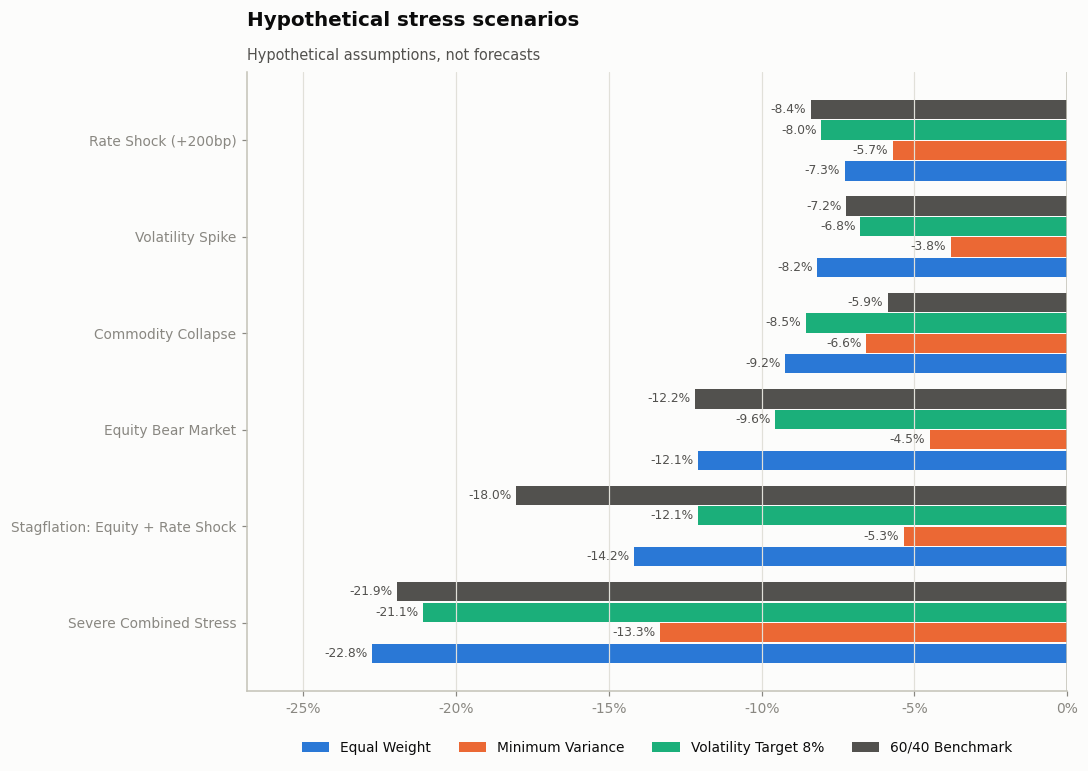

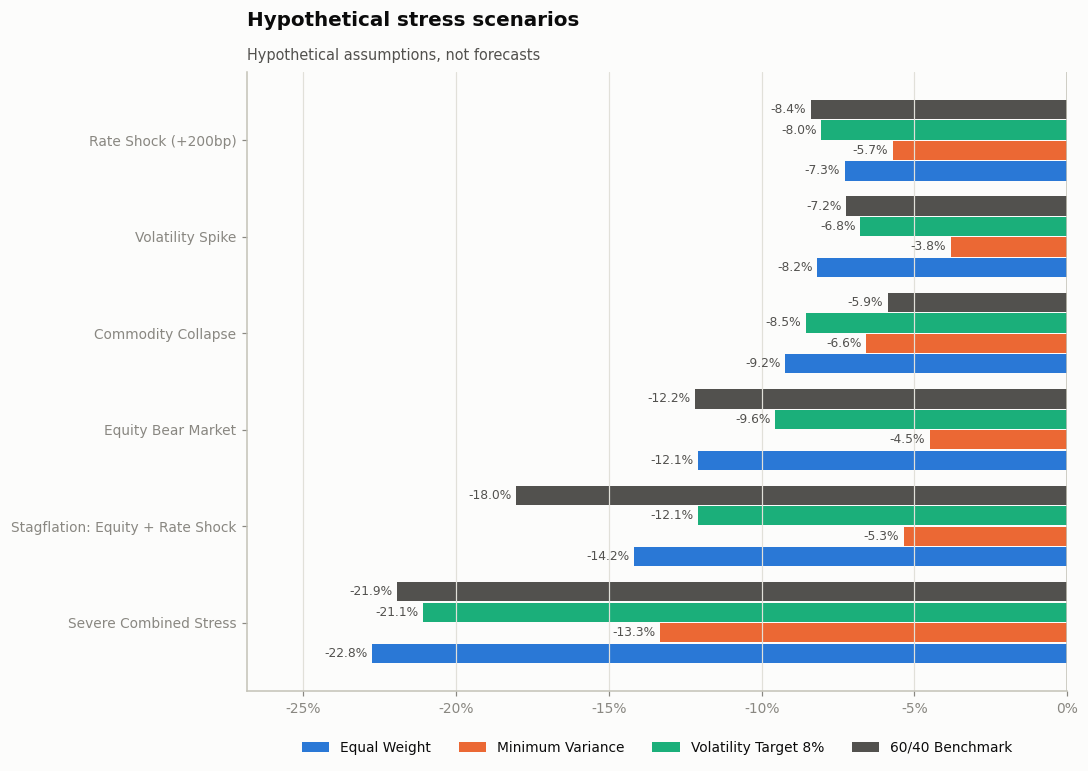

In [7]:
display(plots.plot_stress_scenarios(hypothetical, labels=labels))

In [8]:
assumptions = hypothetical[hypothetical["portfolio"] == "equal_weight"][
    ["scenario", "description", "portfolio_impact", "portfolio_impact_usd",
     "largest_loss_contributor", "largest_loss_contribution"]]
for _, row in assumptions.iterrows():
    print(f"{row['scenario']}")
    print(f"  assumption : {row['description'].strip()}")
    print(f"  impact     : {row['portfolio_impact']:.2%}  "
          f"(${row['portfolio_impact_usd']:,.0f} on ${PORTFOLIO_VALUE:,.0f})")
    print(f"  worst      : {row['largest_loss_contributor']} "
          f"contributing {row['largest_loss_contribution']:.2%}\n")

Equity Bear Market
  assumption : Broad equity decline of 20% with a modest flight to quality that lifts long duration 5%.
  impact     : -12.07%  ($-120,747 on $1,000,000)
  worst      : MSFT contributing -1.84%

Rate Shock (+200bp)
  assumption : Parallel upward shift of 200bp in the curve: long Treasuries -30%, equities -8% on the discount-rate effect, REITs -12% on their duration sensitivity.
  impact     : -7.28%  ($-72,844 on $1,000,000)
  worst      : TLT contributing -1.79%

Commodity Collapse
  assumption : Global demand shock: the commodity complex falls 30%, equities -10%, with a 6% duration rally as growth expectations are marked down.
  impact     : -9.23%  ($-92,301 on $1,000,000)
  worst      : DBC contributing -2.39%

Volatility Spike
  assumption : Sharp risk-off repricing with pairwise correlations converging to 0.90.
  impact     : -8.18%  ($-81,804 on $1,000,000)
  worst      : JPM contributing -1.05%

Stagflation: Equity + Rate Shock
  assumption : Combined shock i

**These are hypothetical stress assumptions, not forecasts.** They are chosen to
probe specific vulnerabilities, and each one is stated in the config file so a reader can
disagree with the number rather than guess at it.

The **Rate Shock** scenario is the one that separates the portfolios most sharply from
their equity-crisis ranking. Minimum variance is the best performer in an equity bear
market and among the worst, relative to its own volatility, in a rate shock — the
substitution effect from notebook 01, priced.

### Asset-level attribution for the severe scenario

In [9]:
primary = cfg.output["primary_portfolio"]
severe = stx.scenario_asset_detail(
    weights_map[primary], returns[holdings], "Severe Combined Stress", cfg)
display(severe.style.format({
    "weight": "{:.2%}", "asset_shock": "{:.2%}",
    "loss_contribution": "{:.2%}", "pct_of_total_impact": "{:.1%}"}))

,weight,asset_shock,loss_contribution,pct_of_total_impact
MSFT,7.87%,-32.24%,-2.54%,12.0%
DBC,11.72%,-20.00%,-2.34%,11.1%
TLT,7.95%,-25.00%,-1.99%,9.4%
AGG,19.19%,-9.27%,-1.78%,8.4%
XOM,6.33%,-25.65%,-1.62%,7.7%
SPY,5.01%,-30.00%,-1.50%,7.1%
AAPL,4.61%,-32.49%,-1.50%,7.1%
VNQ,4.24%,-35.00%,-1.48%,7.0%
JPM,5.06%,-27.38%,-1.39%,6.6%
PG,7.63%,-15.67%,-1.20%,5.7%


## 4. Correlation stress

The most damaging feature of a real crisis is not that any single asset falls further than
expected. It is that everything falls at once, so the diversification the portfolio was
built on stops working exactly when it is needed.

This test isolates that effect: individual volatilities are held **fixed** and only the
correlations move.

In [10]:
for n in order:
    frame = stx.correlation_stress_impact(weights_map[n], cov_recent,
                                          [0.5, 0.75, 0.9, 0.95], cfg.trading_days)
    frame.insert(0, "portfolio", labels[n])
    display(frame.style.format({"annualised_volatility": "{:.2%}",
                                "vol_multiple": "{:.2f}x"}).hide(axis="index"))

portfolio,scenario,annualised_volatility,vol_multiple
Equal Weight,Observed correlations,8.85%,1.00x
Equal Weight,All correlations = 0.50,14.00%,1.58x
Equal Weight,All correlations = 0.75,16.71%,1.89x
Equal Weight,All correlations = 0.90,18.15%,2.05x
Equal Weight,All correlations = 0.95,18.60%,2.10x


portfolio,scenario,annualised_volatility,vol_multiple
Minimum Variance,Observed correlations,4.69%,1.00x
Minimum Variance,All correlations = 0.50,8.35%,1.78x
Minimum Variance,All correlations = 0.75,9.72%,2.07x
Minimum Variance,All correlations = 0.90,10.46%,2.23x
Minimum Variance,All correlations = 0.95,10.70%,2.28x


portfolio,scenario,annualised_volatility,vol_multiple
Volatility Target 8%,Observed correlations,7.64%,1.00x
Volatility Target 8%,All correlations = 0.50,12.80%,1.68x
Volatility Target 8%,All correlations = 0.75,15.29%,2.00x
Volatility Target 8%,All correlations = 0.90,16.61%,2.17x
Volatility Target 8%,All correlations = 0.95,17.03%,2.23x


portfolio,scenario,annualised_volatility,vol_multiple
60/40 Benchmark,Observed correlations,9.95%,1.00x
60/40 Benchmark,All correlations = 0.50,10.52%,1.06x
60/40 Benchmark,All correlations = 0.75,10.96%,1.10x
60/40 Benchmark,All correlations = 0.90,11.22%,1.13x
60/40 Benchmark,All correlations = 0.95,11.30%,1.14x


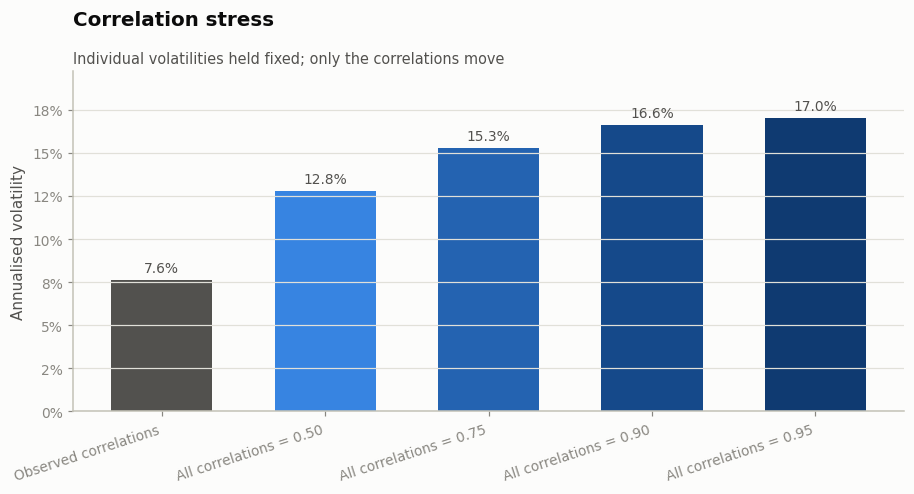

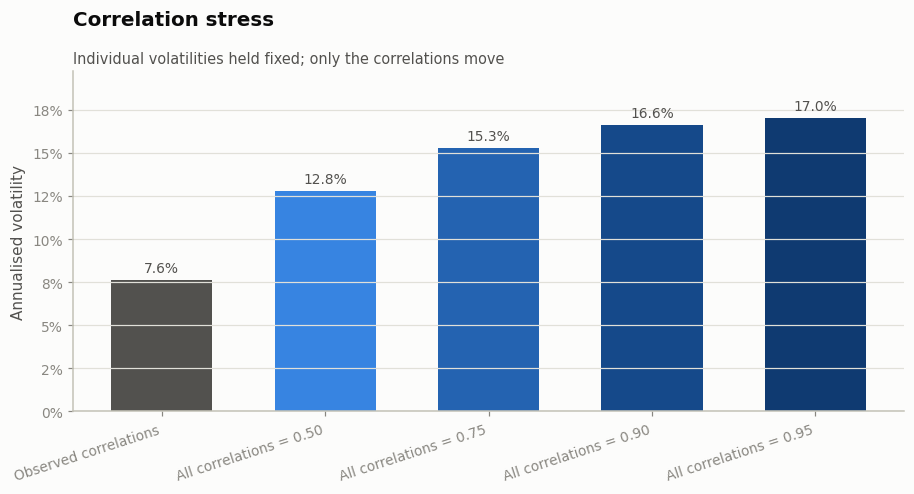

In [11]:
display(plots.plot_correlation_stress(
    stx.correlation_stress_impact(weights_map[primary], cov_recent,
                                  [0.5, 0.75, 0.9, 0.95], cfg.trading_days)))

The portfolios that look safest under observed correlations have the most to
lose when correlations converge, because more of their apparent safety is coming from
diversification rather than from holding genuinely low-volatility assets. Correlation is
a borrowed defence, and it gets recalled under stress.

## 5. VaR backtesting

Now the accountability section. A 99% one-day VaR model makes a testable claim, and two
things have to be checked — both of them matter.

**Unconditional coverage.** Is the *number* of exceptions right? Kupiec's
proportion-of-failures likelihood-ratio test, distributed χ²(1) under the null.

**Independence.** Are the exceptions *spread out*? A model can have exactly the right
exception count and still be useless if every breach arrives in the same fortnight,
because that is precisely when the capital is needed. Christoffersen's Markov test.

The two combine into the conditional-coverage test, χ²(2). Basel traffic-light zones are
reported alongside — defined for 99% models only, so they are suppressed at 95% rather
than labelling every correctly calibrated model red.

Forecasts use a trailing 500-day window and, critically, the forecast for day *t* uses only
returns up to *t-1*. The unit test `test_rolling_forecast_has_no_look_ahead` enforces
this.

In [12]:
backtests = []
for n in order:
    frame = bt.backtest_summary(results[n].returns, confidences=[0.95, 0.99],
                                window=int(cfg.risk["backtest"]["rolling_window"]))
    frame.insert(0, "portfolio", labels[n])
    backtests.append(frame)
backtests = pd.concat(backtests, ignore_index=True)

at99 = backtests[backtests["confidence"] == 0.99]
display(at99[["portfolio", "method", "n_observations", "n_exceptions",
              "expected_exceptions", "observed_rate", "kupiec_p_value",
              "independence_p_value", "basel_zone", "avg_breach_severity"]]
        .style.format({"observed_rate": "{:.3%}", "expected_exceptions": "{:.0f}",
                       "kupiec_p_value": "{:.3f}", "independence_p_value": "{:.3f}",
                       "avg_breach_severity": "{:.2f}"}).hide(axis="index"))

portfolio,method,n_observations,n_exceptions,expected_exceptions,observed_rate,kupiec_p_value,independence_p_value,basel_zone,avg_breach_severity
Equal Weight,historical,4083,48,41,1.176%,0.273,0.000,Green,1.61
Equal Weight,normal,4083,78,41,1.910%,0.000,0.000,Green,1.58
Equal Weight,student_t,4083,43,41,1.053%,0.735,0.000,Green,1.53
Equal Weight,cornish_fisher,4083,29,41,0.710%,0.050,0.000,Green,1.50
Minimum Variance,historical,4083,49,41,1.200%,0.213,0.000,Green,1.55
Minimum Variance,normal,4083,68,41,1.665%,0.000,0.000,Green,1.54
Minimum Variance,student_t,4083,19,41,0.465%,0.000,0.077,Green,1.35
Minimum Variance,cornish_fisher,4083,30,41,0.735%,0.074,0.000,Green,1.50
Volatility Target 8%,historical,4083,50,41,1.225%,0.164,0.000,Green,1.62
Volatility Target 8%,normal,4083,77,41,1.886%,0.000,0.000,Green,1.60


### The headline result

**The parametric-normal model fails, everywhere, decisively.** It breaches roughly twice
as often as it promises, with Kupiec p-values indistinguishable from zero. This is not a
coding artefact — it is the direct, quantified consequence of the excess kurtosis measured
in notebook 02. It is also the single most useful output of the whole project, because it
turns "fat tails matter" from an assertion into a rejected null hypothesis.

**The historical and Student-t models pass on count** for most portfolios.

**Every model fails the independence test.** Exceptions cluster, without exception. This is
volatility clustering, and none of the four methods models it — all of them assume the
distribution is stable over the estimation window. The fix is a conditional volatility
model (GARCH, or EWMA-weighted historical simulation), which is the clearest extension of
this project.

**Average breach severity runs around 1.5 across the board.** When these models are wrong,
the realised loss is about 50% larger than the forecast. Again: this is why ES belongs
next to VaR in any report.

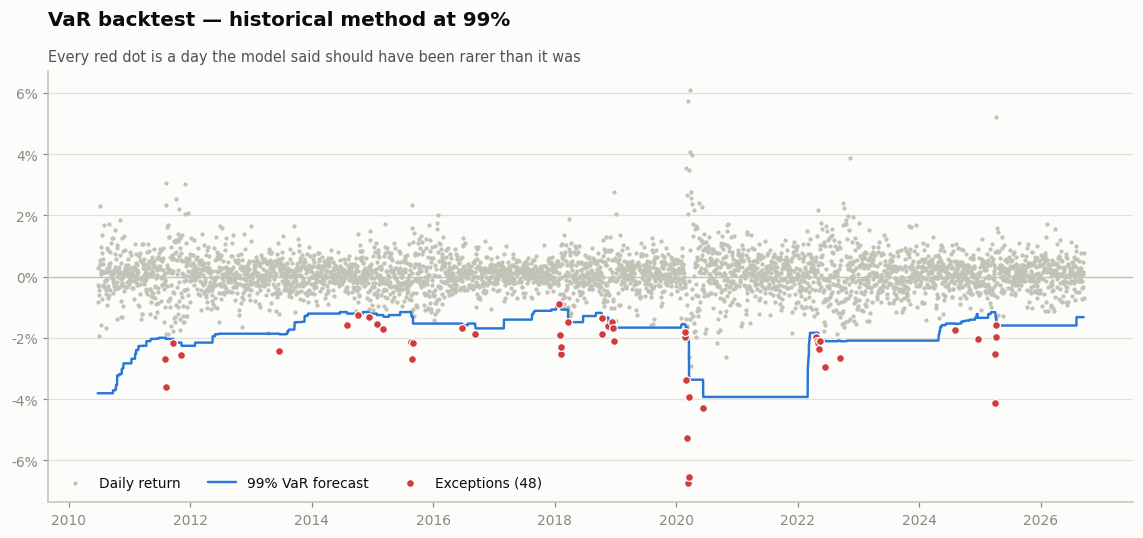

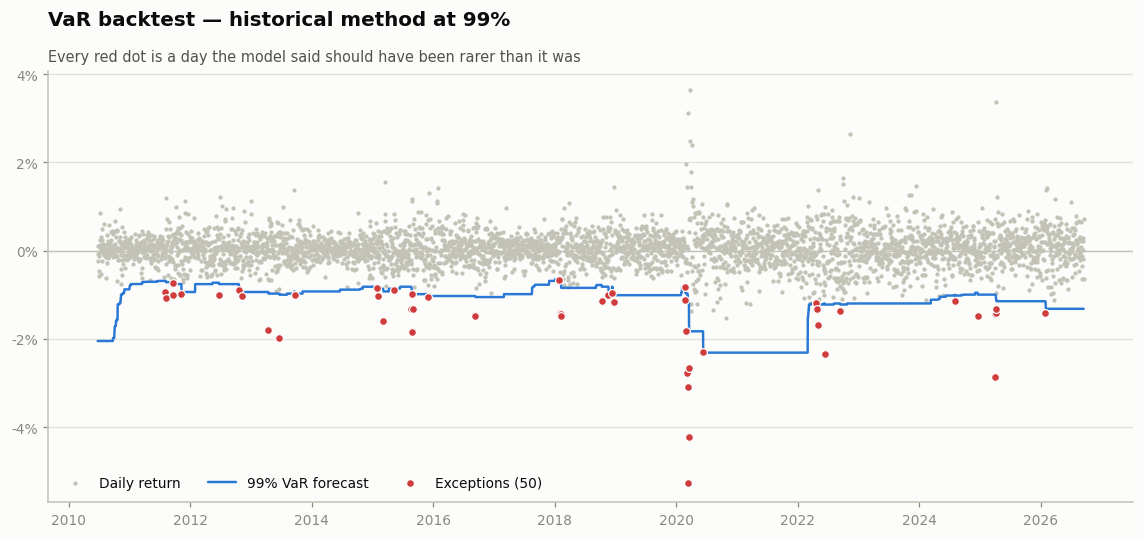

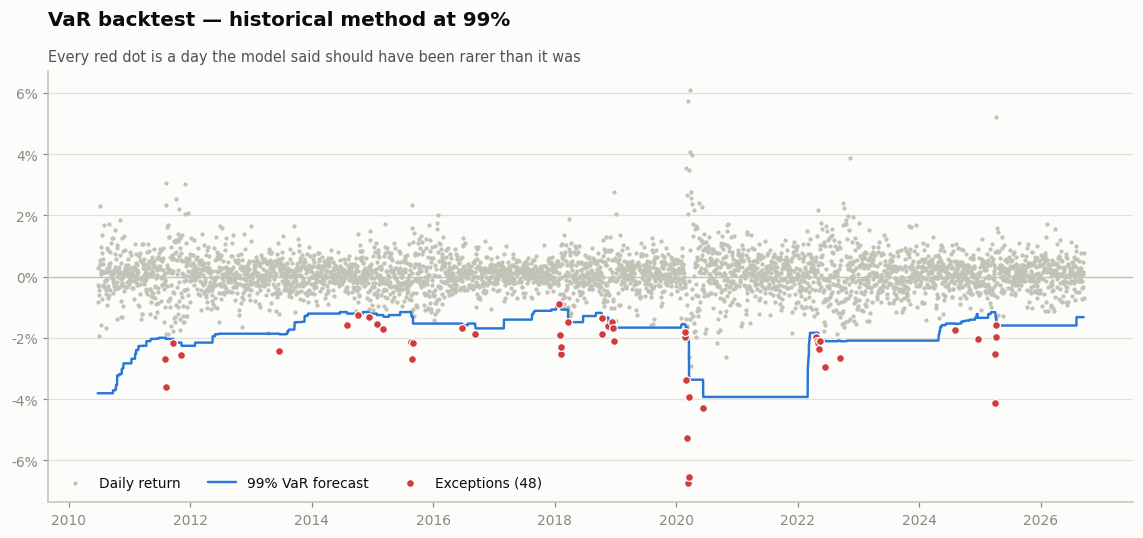

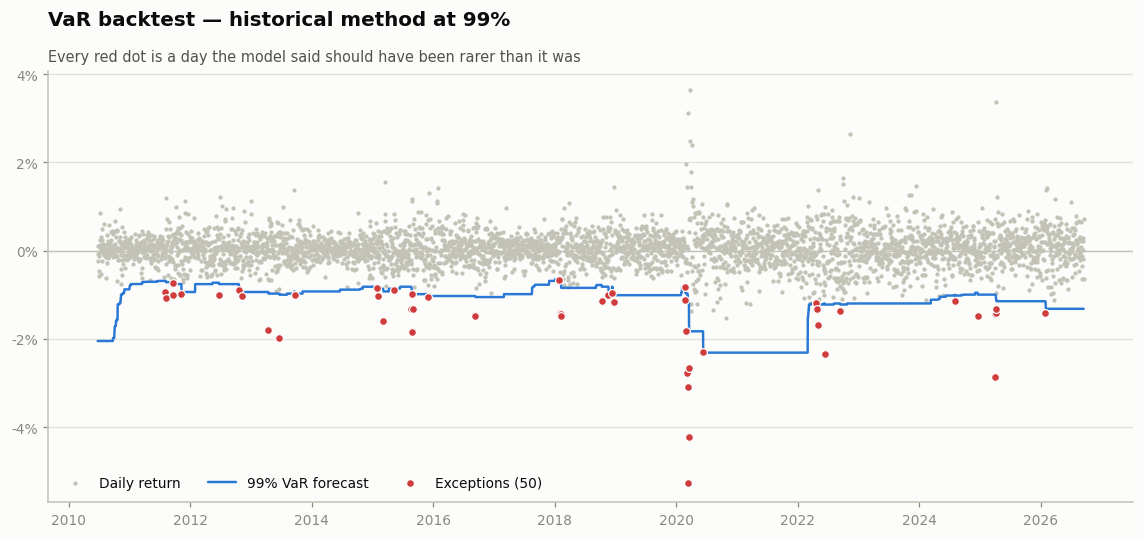

In [13]:
for n in ["equal_weight", cfg.output["primary_portfolio"]]:
    result = bt.backtest_var(results[n].returns,
                             window=int(cfg.risk["backtest"]["rolling_window"]),
                             confidence=0.99, method="historical")
    display(plots.plot_var_backtest(result.realised, result.forecasts,
                                    result.exceptions, 0.99, "historical"))

The chart shows the failure mode better than any test statistic. The historical
VaR forecast is a **step function**: it stays flat for long stretches, then jumps after a
crisis has already happened. In early 2020 it sat at its calm-regime level while the
portfolio lost multiples of it on consecutive days, and only then reset upwards — at which
point the danger had passed and the model spent the next two years being too conservative.

A 500-day window weights a stale observation exactly like yesterday's. That is the price of
making no distributional assumption.

,observations,exceptions,worst_loss,average_var,exception_rate
year,,,,,
2010,133,0,-0.76%,1.61%,0.00%
2011,252,5,-1.06%,0.75%,1.98%
2012,250,3,-1.03%,0.80%,1.20%
2013,252,3,-1.97%,0.96%,1.19%
2014,252,0,-0.82%,0.89%,0.00%
2015,252,9,-1.84%,0.90%,3.57%
2016,252,1,-1.47%,1.03%,0.40%
2017,251,0,-0.63%,0.91%,0.00%
2018,251,8,-1.48%,0.83%,3.19%


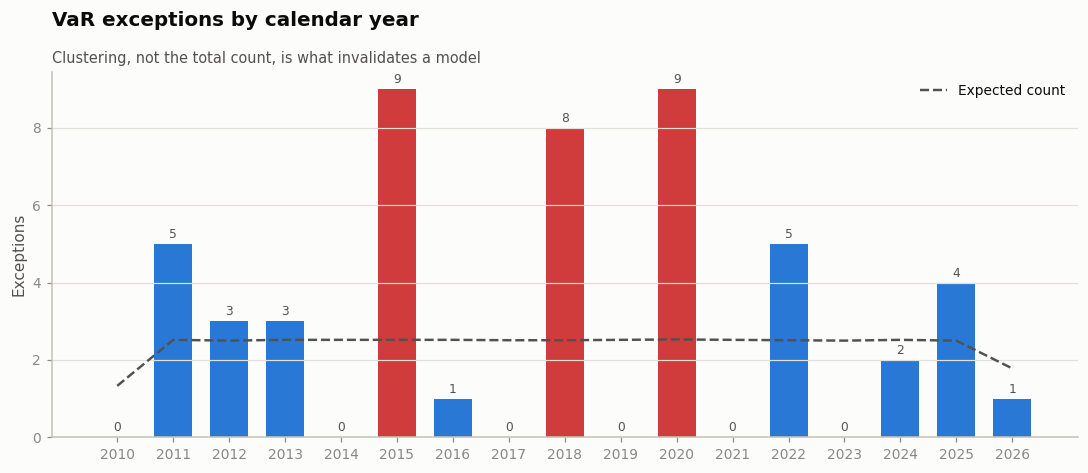

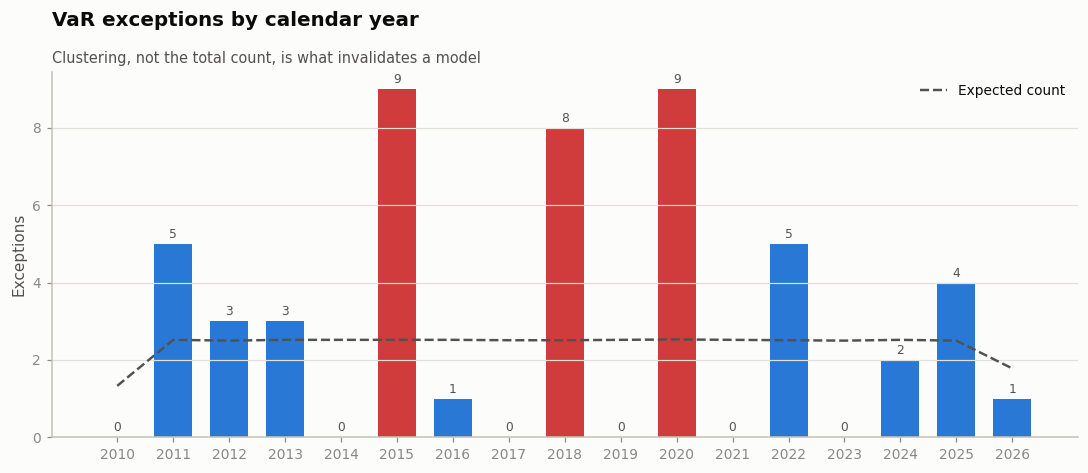

In [14]:
primary_result = bt.backtest_var(
    results[primary].returns, window=int(cfg.risk["backtest"]["rolling_window"]),
    confidence=0.99, method="historical")
by_year = bt.exceptions_by_year(primary_result)
display(by_year.style.format({"worst_loss": "{:.2%}", "average_var": "{:.2%}",
                              "exception_rate": "{:.2%}"}))
display(plots.plot_exceptions_by_year(by_year, 0.99))

The year view makes the clustering unmissable. Most years sit at or below the
expected count; 2020 and 2022 absorb a disproportionate share of all breaches. A model
that is right on average and wrong when it matters is not a model a risk manager can
size positions with.

### Comparing the methods head to head

In [15]:
ranking = at99.copy()
ranking["exception_error"] = (ranking["n_exceptions"] -
                              ranking["expected_exceptions"]).abs()
summary = ranking.groupby("method").agg(
    mean_exceptions=("n_exceptions", "mean"),
    expected=("expected_exceptions", "mean"),
    mean_abs_error=("exception_error", "mean"),
    kupiec_failures=("kupiec_reject", "sum"),
    mean_severity=("avg_breach_severity", "mean"),
).sort_values("mean_abs_error")
display(summary.style.format({
    "mean_exceptions": "{:.1f}", "expected": "{:.1f}", "mean_abs_error": "{:.1f}",
    "mean_severity": "{:.2f}"}))

,mean_exceptions,expected,mean_abs_error,kupiec_failures,mean_severity
method,,,,,
cornish_fisher,31.2,40.8,9.6,1,1.49
historical,50.5,40.8,9.7,1,1.57
student_t,36.0,40.8,11.5,1,1.53
normal,78.5,40.8,37.7,4,1.57


## Takeaways

1. The GFC remains the worst historical episode for three of four portfolios; for the
   60/40 benchmark it is worse than for the equal-weighted portfolio.
2. 2022 is the episode that breaks the usual ranking, because bonds stopped hedging
   equities.
3. Reducing equity risk substitutes duration risk. Minimum variance is best in an equity
   bear market and relatively worst in a rate shock.
4. Portfolios that rely on diversification lose the most when correlations converge.
5. **Parametric-normal VaR is rejected at 99% for every portfolio**, breaching about twice
   as often as advertised.
6. **Every method fails the independence test.** Exceptions cluster, because no method here
   models volatility clustering.
7. Average breach severity ≈ 1.5: when the models are wrong, they are badly wrong.

## Limitations, stated plainly

- No conditional volatility model (GARCH/EWMA). This is the largest single gap and it is
  visible in every independence test.
- The universe is a fixed, survivorship-biased set chosen with hindsight in 2026.
- Transaction costs are a flat 5bp with no market-impact or liquidity modelling.
- Factor betas for the stress scenarios are estimated in normal conditions and applied to
  abnormal ones, which is exactly when they are least reliable.
- The sample contains one rate-shock regime. Conclusions about duration risk rest on a
  single episode.
- Monte Carlo uses a Student-t with a floored ν; the fit itself indicates a regime mixture
  rather than a single fat-tailed distribution.